> Versión con checkpoint. Cambios frente a `RD_02_APTOS_EyePACS_v3.ipynb`.
> 1. Checkpoint por época en Drive, en `<version>_checkpoint.pt`. Si Colab se desconecta, usa *Entorno de ejecución → Ejecutar todas* y el entrenamiento sigue desde la última época terminada.
> 2. `kaggle.json` se lee desde Drive, en `Retinopatia_modelos/kaggle.json`, así que ya no hay que subirlo a mano en cada sesión.
> 3. Al retomar se verifica que la división de datos y `CONFIG` sean idénticas. Si no lo son, se detiene en vez de mezclar entrenamientos.
>
> Antes de un entrenamiento largo, en Windows ve a *Configuración → Sistema → Energía → Suspender → Nunca* cuando esté enchufada.


# Retinopatía Diabética. Primer modelo real, v1
Desafío Cleveland Clinic–UTEC 2026 · Equipo Cristóbal, Rodrigo y Diego

Este cuaderno le enseña a una red neuronal a mirar fotos de fondo de ojo y a decidir si el paciente es referible, es decir, si necesita ir al oftalmólogo por tener ICDR 2 o más, o no referible, con ICDR 0 o 1.

Para usarlo, ejecuta los bloques en orden y uno por uno, con el botón ▶ a la izquierda de cada bloque o con `Shift + Enter`. Antes de cada bloque de código hay una explicación de qué hace y qué principio de ML usa.

<table>
<thead><tr><th>Paso</th><th>Qué pasa</th><th>Tiempo aprox.</th></tr></thead>
<tbody><tr><td>0</td><td>Activar la GPU y preparar el entorno</td><td>2 min</td></tr></tbody>
<tbody><tr><td>1</td><td>Descargar las fotos de APTOS 2019</td><td>5–10 min</td></tr></tbody>
<tbody><tr><td>2</td><td>Preprocesar las fotos</td><td>3–5 min</td></tr></tbody>
<tbody><tr><td>3</td><td>Dividir en estudio / práctica / examen</td><td>segundos</td></tr></tbody>
<tbody><tr><td>4</td><td>Preparar el modelo con transfer learning</td><td>segundos</td></tr></tbody>
<tbody><tr><td>5</td><td>Entrenar</td><td>15–25 min</td></tr></tbody>
<tbody><tr><td>6</td><td>Examen final + métricas con intervalos de confianza</td><td>1 min</td></tr></tbody>
<tbody><tr><td>7</td><td>Guardar <code>model_v1</code></td><td>segundos</td></tr></tbody>
</table>

## Paso 0. Activar la GPU

Antes de ejecutar nada, ve al menú Entorno de ejecución → Cambiar tipo de entorno de ejecución → GPU T4 → Guardar.

La GPU es un procesador especializado en hacer millones de multiplicaciones a la vez, que es justo lo que necesita una red neuronal. Sin GPU, el entrenamiento tardaría horas en lugar de minutos.

El siguiente bloque comprueba que la GPU esté activa.

In [20]:
import torch
if torch.cuda.is_available():
    print("GPU activa:", torch.cuda.get_device_name(0))
else:
    print("NO hay GPU. Ve a 'Entorno de ejecución → Cambiar tipo de entorno' y elige GPU T4.")

GPU activa: Tesla T4


In [21]:
!df -h /content

Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   45G   69G  40% /


### Instalar librerías
- PyTorch es la librería base para construir y entrenar redes neuronales y ya viene en Colab.
- timm es una "tienda" de modelos ya entrenados, y de aquí sacamos EfficientNet-B0.
- OpenCV, que se importa como cv2, sirve para procesar imágenes.

In [22]:
!pip install -q timm

### Configuración general
Aquí están todos los "ajustes" del experimento en un solo lugar. Si luego quieres probar variaciones, como más épocas u otro tamaño de imagen, solo cambias esto.

- `tam_imagen` es el tamaño en píxeles al que se reducen las fotos, 384×384.
- `batch` es cuántas fotos ve el modelo a la vez antes de corregirse, 32.
- `epocas` es cuántas veces el modelo repasa todas las fotos de estudio.
- `lr`, *learning rate* o tasa de aprendizaje, es qué tan grande es cada corrección. Muy grande → aprende "a saltos" y no converge. Muy pequeña → aprende lentísimo.
- `semilla` fija el azar para que el resultado sea reproducible, así que si lo corres de nuevo sale lo mismo.
- `sensibilidad_objetivo` existe porque en tamizaje no queremos que se escapen enfermos, así que fijamos el umbral de decisión para detectar al menos el 90%.

In [26]:
CONFIG = dict(
    tam_imagen=384,
    batch=32,
    epocas=12,
    lr=3e-4,
    semilla=42,
    usar_clahe=False,          # mejora de contraste opcional, por probar en v2
    modelo="efficientnet_b0",
    version="model_v3",
    sensibilidad_objetivo=0.90,
)

import os, random, glob, shutil, zipfile, numpy as np
CARPETA_DATOS = "/content/aptos"                 # fotos originales
CARPETA_PREP  = "/content/aptos_prep"            # fotos preprocesadas
CARPETA_SALIDA = "/content/drive/MyDrive/Retinopatia_modelos LOCAL"

def fijar_semilla(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
fijar_semilla(CONFIG["semilla"])
print(CONFIG)

{'tam_imagen': 384, 'batch': 32, 'epocas': 12, 'lr': 0.0003, 'semilla': 42, 'usar_clahe': False, 'modelo': 'efficientnet_b0', 'version': 'model_v3', 'sensibilidad_objetivo': 0.9}


### Conectar Google Drive
Colab borra todo al cerrar la sesión. Por eso guardamos el modelo entrenado y las fotos preprocesadas en la carpeta `Retinopatia_modelos` de tu Google Drive. Te pedirá permiso para acceder a tu Drive y tienes que aceptar.

In [27]:
from google.colab import drive
drive.mount("/content/drive")
os.makedirs(CARPETA_SALIDA, exist_ok=True)
print("Los resultados se guardarán en:", CARPETA_SALIDA)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Los resultados se guardarán en: /content/drive/MyDrive/Retinopatia_modelos LOCAL


## Paso 1. Descargar las fotos de APTOS 2019

APTOS 2019 son unas 3,662 fotos de retina tomadas en India, cada una calificada por oftalmólogos en la escala ICDR de 0 a 4.

<table>
<thead><tr><th>Grado</th><th>Significado</th><th>Nuestra etiqueta</th></tr></thead>
<tbody><tr><td>0</td><td>Sin retinopatía</td><td>No referible</td></tr></tbody>
<tbody><tr><td>1</td><td>Leve</td><td>No referible</td></tr></tbody>
<tbody><tr><td>2</td><td>Moderada</td><td>Referible</td></tr></tbody>
<tbody><tr><td>3</td><td>Severa</td><td>Referible</td></tr></tbody>
<tbody><tr><td>4</td><td>Proliferativa</td><td>Referible</td></tr></tbody>
</table>

Esa calificación del oftalmólogo es la "respuesta correcta" de la que aprende el modelo → esto es aprendizaje supervisado.

### Antes de ejecutar, solo la primera vez
1. Entra a https://www.kaggle.com/competitions/aptos2019-blindness-detection → pestaña Rules → "I understand and accept". Sin esto, la descarga da error 403.
2. En Kaggle ve a tu foto de perfil → Settings → API → Create New Token. Se descarga un archivo `kaggle.json`, que es tu "llave".
3. Sube ese `kaggle.json` una sola vez a tu Google Drive, en la carpeta `Retinopatia_modelos/`, la misma donde se guardan los modelos. El cuaderno lo lee de ahí en cada sesión. Es tu llave personal, así que no compartas esa carpeta con nadie mientras el archivo esté ahí.

> Si ya ejecutaste el Paso 2 en una sesión anterior, el bloque detecta las fotos preprocesadas en tu Drive y se salta la descarga.

In [28]:
# Llave de Kaggle leída desde tu Drive. Sube kaggle.json una sola vez a Retinopatia_modelos/
def instalar_llave_kaggle():
    origen = f"{CARPETA_SALIDA}/kaggle.json"
    assert os.path.exists(origen), f"No encuentro {origen}. Sube tu kaggle.json a esa carpeta de Drive."
    os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
    destino = os.path.expanduser("~/.kaggle/kaggle.json")
    shutil.copy(origen, destino)
    os.chmod(destino, 0o600)

CACHE_DRIVE = f"{CARPETA_SALIDA}/aptos_prep_{CONFIG['tam_imagen']}.zip"

if os.path.exists(CACHE_DRIVE):
    print("Encontré fotos preprocesadas en tu Drive. Me salto la descarga.")
    with zipfile.ZipFile(CACHE_DRIVE) as z:
        z.extractall("/content")
    shutil.copy(f"{CARPETA_SALIDA}/train.csv", "/content/train.csv")
else:
    instalar_llave_kaggle()
    !kaggle competitions download -c aptos2019-blindness-detection -p {CARPETA_DATOS}
    # Solo descomprimimos las fotos de entrenamiento, porque las de 'test' no traen diagnóstico
    !unzip -q -o {CARPETA_DATOS}/aptos2019-blindness-detection.zip "train_images/*" "train.csv" -d {CARPETA_DATOS}
    shutil.copy(f"{CARPETA_DATOS}/train.csv", "/content/train.csv")
    print("Descarga lista:", len(glob.glob(f"{CARPETA_DATOS}/train_images/*.png")), "fotos")

Encontré fotos preprocesadas en tu Drive. Me salto la descarga.


### Mirar los datos
Cargamos la tabla de etiquetas y creamos nuestro esquema común con las columnas `image_id, ruta_archivo, icdr_grade, source_dataset`. Es el mismo formato que usaremos cuando sumemos EyePACS, IDRiD, DDR y mBRSET, para que todos los datasets "hablen el mismo idioma".

In [ ]:
import pandas as pd
df = pd.read_csv("/content/train.csv")  # columnas id_code y diagnosis
df = pd.DataFrame({
    "image_id": df["id_code"],
    "ruta_archivo": CARPETA_DATOS + "/train_images/" + df["id_code"] + ".png",
    "icdr_grade": df["diagnosis"].astype(int),
    "source_dataset": "APTOS2019",
})
df["referible"] = (df["icdr_grade"] >= 2).astype(int)

print("Total de fotos:", len(df))
print("\nFotos por grado ICDR:")
print(df["icdr_grade"].value_counts().sort_index())
print("\nReferible (1) vs No referible (0):")
print(df["referible"].value_counts())

Total de fotos: 3662

Fotos por grado ICDR:
icdr_grade
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64

Referible (1) vs No referible (0):
referible
0    2175
1    1487
Name: count, dtype: int64


EyePACS

In [29]:
# ── Paso 1. Sumar EyePACS ──

# Autenticación con Kaggle. La llave se lee de tu Drive, sin subir nada a mano
instalar_llave_kaggle()

CARPETA_EYEPACS_LISTO = "/content/eyepacs_384"
os.makedirs(CARPETA_EYEPACS_LISTO, exist_ok=True)

!kaggle datasets download -d cristbalmontoyabao/atros-dataset -p {CARPETA_EYEPACS_LISTO}
!unzip -q -o {CARPETA_EYEPACS_LISTO}/*.zip -d {CARPETA_EYEPACS_LISTO}
!rm -f {CARPETA_EYEPACS_LISTO}/*.zip

# Buscar automáticamente dónde quedó etiquetas.csv, por si Kaggle anidó una carpeta extra
import glob
rutas_csv = glob.glob(f"{CARPETA_EYEPACS_LISTO}/**/etiquetas.csv", recursive=True)
print("CSV encontrado en:", rutas_csv)
ruta_csv = rutas_csv[0]
CARPETA_FOTOS_EYEPACS = os.path.dirname(ruta_csv)
print("Fotos en:", CARPETA_FOTOS_EYEPACS)

t = pd.read_csv(ruta_csv)

df_eyepacs = pd.DataFrame({
    "image_id":       t["image_id"],
    "ruta_archivo":   f"{CARPETA_FOTOS_EYEPACS}/" + t["image_id"] + ".jpg",
    "icdr_grade":     t["icdr_grade"].astype(int),
    "source_dataset": "EyePACS",
    "patient_id":     t["patient_id"],
    "ojo":            t["ojo"],
    "dispositivo":    "camara_mesa",
})
df_eyepacs["referible"] = (df_eyepacs["icdr_grade"] >= 2).astype(int)

# Completar en df, que tiene APTOS, las columnas que EyePACS sí trae y APTOS no
df["patient_id"] = df["image_id"]
df["ojo"] = "desconocido"
df["dispositivo"] = "camara_mesa"

df = pd.concat([df, df_eyepacs], ignore_index=True)

print("Total combinado:", len(df), "fotos")
print(df["source_dataset"].value_counts())

Dataset URL: https://www.kaggle.com/datasets/cristbalmontoyabao/atros-dataset
License(s): unknown
100% 925M/925M [00:09<00:00, 97.3MB/s]

CSV encontrado en: ['/content/eyepacs_384/eyepacs_384/etiquetas.csv']
Fotos en: /content/eyepacs_384/eyepacs_384
Total combinado: 38788 fotos
source_dataset
EyePACS      35126
APTOS2019     3662
Name: count, dtype: int64


In [30]:
import os

es_aptos = df["source_dataset"] == "APTOS2019"   # APTOS viene preprocesado desde el caché de Drive
existe = es_aptos | df["ruta_archivo"].apply(os.path.exists)
print("Fotos con ruta válida:", existe.sum(), "de", len(df))
print("Fotos eliminadas por ruta rota:", (~existe).sum())
if (~existe).sum() > 0:
    print(df[~existe][["source_dataset", "image_id", "ruta_archivo"]])

df = df[existe].reset_index(drop=True)

Fotos con ruta válida: 38787 de 38788
Fotos eliminadas por ruta rota: 1
      source_dataset    image_id  \
16438        EyePACS  16028_left   

                                          ruta_archivo  
16438  /content/eyepacs_384/eyepacs_384/16028_left.jpg  


In [31]:
# ── Unificar patient_id como texto con prefijo de la base, porque EyePACS trae números y APTOS texto y no se pueden mezclar ──
# se puede correr varias veces sin problema
df["patient_id"] = df["source_dataset"] + "_" + df["patient_id"].astype(str).str.replace(r"^(APTOS2019|EyePACS)_", "", regex=True)
assert df["patient_id"].map(type).eq(str).all(), "patient_id sigue con tipos mezclados"

# ── Control de seguridad ANTES de seguir, se detiene si algo no cuadra ──
conteo = df["source_dataset"].value_counts().to_dict()
print("Fotos por base:", conteo)
assert conteo.get("APTOS2019", 0) == 3662, f"APTOS no está completa: {conteo}"
assert conteo.get("EyePACS", 0) >= 35000, f"EyePACS no está completa: {conteo}"
assert not df.duplicated(["source_dataset", "image_id"]).any(), "Hay fotos duplicadas (¿corriste dos veces la celda de EyePACS?). Vuelve a correr desde 'Mirar los datos'."
assert df[["image_id", "icdr_grade", "patient_id", "referible"]].notna().all().all(), "Faltan datos en columnas clave"
print("OK df tiene las dos bases, sin duplicados:", len(df), "fotos | ejemplo patient_id:", df.patient_id.iloc[[0,-1]].tolist())

Fotos por base: {'EyePACS': 35125, 'APTOS2019': 3662}
OK df tiene las dos bases, sin duplicados: 38787 fotos | ejemplo patient_id: ['APTOS2019_000c1434d8d7', 'EyePACS_44349']


## Paso 2. Preprocesar las fotos

Las fotos de retina vienen con bordes negros, tamaños distintos, algunas de 3000 px, e iluminación desigual. Si no las "limpiamos", el modelo podría aprender cosas irrelevantes en vez de las lesiones, por ejemplo el tamaño del borde negro de cierta cámara.

La función `preprocesar_imagen` hace 3 cosas.
1. Recorta el borde negro, dejando solo el círculo de la retina.
2. La vuelve cuadrada rellenando con negro y la reduce a 384×384.
3. De forma opcional aplica CLAHE, que realza el contraste local para que microaneurismas y hemorragias resalten.

Está escrita como función reusable, así que la misma se aplicará a las fotos de smartphone de mBRSET cuando llegue el acceso de PhysioNet. Es importante que *todas* las fotos pasen por el mismo procesamiento.

Se guardan las fotos ya procesadas, con una copia en tu Drive, para no repetir este trabajo en cada época.

In [32]:
import cv2
from concurrent.futures import ThreadPoolExecutor
from tqdm.auto import tqdm

def preprocesar_imagen(ruta, tam=384, usar_clahe=False, tolerancia=10):
    img = cv2.imread(ruta)                       # lee la foto en formato BGR
    if img is None:
        raise FileNotFoundError(ruta)
    gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    mascara = gris > tolerancia                  # píxeles que NO son borde negro
    if mascara.any():
        filas = np.where(mascara.any(axis=1))[0]
        cols = np.where(mascara.any(axis=0))[0]
        img = img[filas[0]:filas[-1] + 1, cols[0]:cols[-1] + 1]   # 1. recorte
    h, w = img.shape[:2]
    lado = max(h, w)                             # 2. volver cuadrada
    lienzo = np.zeros((lado, lado, 3), dtype=img.dtype)
    lienzo[(lado - h) // 2:(lado - h) // 2 + h, (lado - w) // 2:(lado - w) // 2 + w] = img
    img = cv2.resize(lienzo, (tam, tam), interpolation=cv2.INTER_AREA)
    if usar_clahe:                               # 3. contraste opcional
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        lab[..., 0] = clahe.apply(lab[..., 0])
        img = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
    return img

os.makedirs(CARPETA_PREP, exist_ok=True)
df["ruta_prep"] = CARPETA_PREP + "/" + df["source_dataset"] + "_" + df["image_id"].astype(str).str.replace("/", "_") + ".jpg"

def procesar_y_guardar(fila):
    if not os.path.exists(fila.ruta_prep):
        img = preprocesar_imagen(fila.ruta_archivo, CONFIG["tam_imagen"], CONFIG["usar_clahe"])
        cv2.imwrite(fila.ruta_prep, img, [cv2.IMWRITE_JPEG_QUALITY, 95])

pendientes = [f for f in df.itertuples() if not os.path.exists(f.ruta_prep)]
if pendientes:
    with ThreadPoolExecutor(max_workers=8) as ex:
        list(tqdm(ex.map(procesar_y_guardar, pendientes), total=len(pendientes), desc="Preprocesando"))
faltan = [r for r in df["ruta_prep"] if not os.path.exists(r)]
assert not faltan, f"Faltan {len(faltan)} fotos preprocesadas, p. ej.: {faltan[:3]}"
print("Fotos preprocesadas:", len(glob.glob(CARPETA_PREP + "/*.jpg")), "| todas las de df existen ")

Fotos preprocesadas: 38787 | todas las de df existen


In [ ]:
# Copia de seguridad en Drive, así la próxima sesión no hay que descargar de nuevo
if not os.path.exists(CACHE_DRIVE):
    shutil.make_archive(CACHE_DRIVE[:-4], "zip", "/content", os.path.basename(CARPETA_PREP))
    shutil.copy("/content/train.csv", f"{CARPETA_SALIDA}/train.csv")
    print("Copia guardada en Drive:", CACHE_DRIVE)

### Ver ejemplos
Una foto de cada grado, ya preprocesada. Fíjate cómo en los grados altos aparecen puntos rojos, que son hemorragias, manchas amarillas, que son exudados, y en el grado 4 vasos anormales.

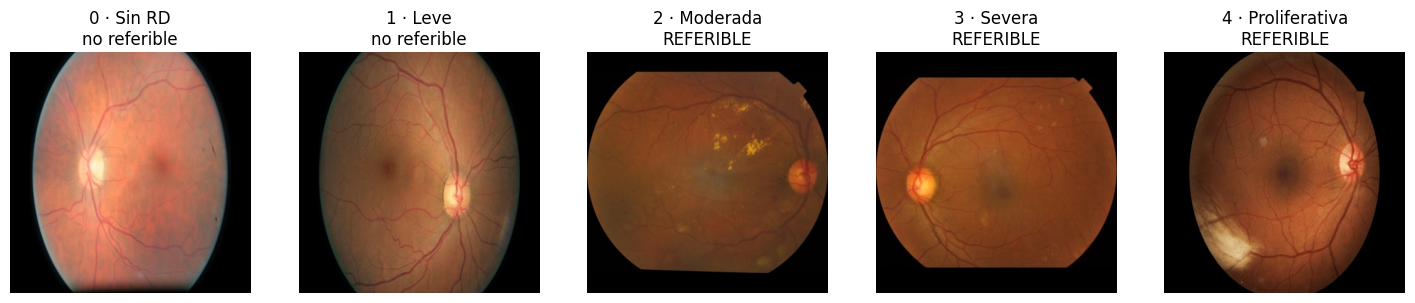

In [33]:
import matplotlib.pyplot as plt
nombres = ["0 · Sin RD", "1 · Leve", "2 · Moderada", "3 · Severa", "4 · Proliferativa"]
fig, ejes = plt.subplots(1, 5, figsize=(18, 4))
for g in range(5):
    fila = df[df.icdr_grade == g].sample(1, random_state=CONFIG["semilla"]).iloc[0]
    ejes[g].imshow(cv2.cvtColor(cv2.imread(fila.ruta_prep), cv2.COLOR_BGR2RGB))
    ejes[g].set_title(nombres[g] + ("\nREFERIBLE" if g >= 2 else "\nno referible"))
    ejes[g].axis("off")
plt.show()

## Paso 3. Dividir en estudio / práctica / examen

<table>
<thead><tr><th>Conjunto</th><th>%</th><th>Para qué</th></tr></thead>
<tbody><tr><td>Entrenamiento, train</td><td>70%</td><td>El modelo estudia con estas fotos</td></tr></tbody>
<tbody><tr><td>Validación, val</td><td>15%</td><td>"Exámenes de práctica" durante el estudio, con los que elegimos la mejor época y el umbral de decisión</td></tr></tbody>
<tbody><tr><td>Prueba, test</td><td>15%</td><td>Examen final. El modelo NUNCA las ve antes. Este es el número que se reporta</td></tr></tbody>
</table>

¿Por qué? Para detectar el sobreajuste u *overfitting*. Un modelo puede *memorizar* las fotos de estudio en vez de *entender* el patrón, y solo un examen con fotos nuevas lo revela.

La división es estratificada, así que cada conjunto mantiene la misma proporción de grados del 0 al 4 y el examen es representativo.

> Limitación honesta. APTOS no publica un identificador de paciente, así que aquí la división es por imagen. Cuando sumemos EyePACS, que sí indica paciente y ojo, haremos la división por paciente, para que los dos ojos de una persona no queden uno en "estudio" y otro en "examen".

In [34]:
assert df["patient_id"].map(type).eq(str).all(), "patient_id con tipos mezclados: corre antes la celda 'Control de seguridad'"

from sklearn.model_selection import StratifiedGroupKFold

def separar(d, n_splits):
    sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=CONFIG["semilla"])
    resto_idx, fold_idx = next(sgkf.split(d, d.icdr_grade, groups=d.patient_id))
    return d.iloc[resto_idx], d.iloc[fold_idx]

df_trainval, df_test = separar(df, 7)       # ~14% examen final
df_train, df_val     = separar(df_trainval, 6)   # ~14% práctica

# Control de que ningún paciente aparezca en dos conjuntos
assert not set(df_train.patient_id) & set(df_test.patient_id)
assert not set(df_train.patient_id) & set(df_val.patient_id)
assert not set(df_val.patient_id)   & set(df_test.patient_id)

for nombre, d in [("Entrenamiento", df_train), ("Validación", df_val), ("Prueba", df_test)]:
    print(f"{nombre:14s}: {len(d):5d} fotos | referibles: {d.referible.mean():.0%}")

# Control de que las 3 particiones sumen el total y tengan AMBAS bases
assert len(df_train) + len(df_val) + len(df_test) == len(df), "Las particiones no suman el total"
for nombre, d in [("Entrenamiento", df_train), ("Validación", df_val), ("Prueba", df_test)]:
    assert d.source_dataset.nunique() == 2, f"{nombre} no tiene las dos bases: {d.source_dataset.value_counts().to_dict()}"
print("OK las 3 particiones suman", len(df), "y todas tienen APTOS y EyePACS")

Entrenamiento : 27706 fotos | referibles: 21%
Validación    :  5541 fotos | referibles: 21%
Prueba        :  5540 fotos | referibles: 22%
OK las 3 particiones suman 38787 y todas tienen APTOS y EyePACS


## Paso 4. Preparar los datos para el modelo y el modelo

### Aumento de datos o *data augmentation*
Durante el estudio, cada vez que el modelo ve una foto se la mostramos ligeramente distinta, girada, volteada, con otro brillo o contraste. Así aprende que una hemorragia es una hemorragia aunque la foto salga torcida u oscura, algo clave para las cámaras reales del MINSA. En validación y prueba no se altera nada, porque el examen debe ser con fotos "tal cual".

### Normalización
Las redes preentrenadas en ImageNet esperan los colores en una escala específica, con la media y la desviación estándar de ImageNet. Ajustamos nuestras fotos a esa escala.

In [35]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

MEDIA, DESV = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]   # valores de ImageNet
t_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(MEDIA, DESV),
])
t_eval = transforms.Compose([transforms.ToTensor(), transforms.Normalize(MEDIA, DESV)])

class RetinaDataset(Dataset):
    # Le entrega al modelo pares de foto y respuesta correcta
    def __init__(self, tabla, transformacion):
        self.tabla = tabla.reset_index(drop=True)
        self.t = transformacion
    def __len__(self):
        return len(self.tabla)
    def __getitem__(self, i):
        fila = self.tabla.iloc[i]
        img = Image.open(fila.ruta_prep).convert("RGB")
        return self.t(img), torch.tensor(fila.referible, dtype=torch.float32)

NW = 2
dl_train = DataLoader(RetinaDataset(df_train, t_train), batch_size=CONFIG["batch"], shuffle=True, num_workers=NW, pin_memory=True)
dl_val   = DataLoader(RetinaDataset(df_val, t_eval),   batch_size=CONFIG["batch"], shuffle=False, num_workers=NW)
dl_test  = DataLoader(RetinaDataset(df_test, t_eval),  batch_size=CONFIG["batch"], shuffle=False, num_workers=NW)
print("Lotes por época:", len(dl_train))

Lotes por época: 866


### El modelo, EfficientNet-B0 con *transfer learning*

- La red neuronal convolucional o CNN analiza la imagen por capas, primero bordes y colores → luego formas y puntos → al final patrones con significado como microaneurismas, hemorragias y exudados.
- Con transfer learning partimos de EfficientNet-B0, que ya aprendió a "mirar" con más de 1 millón de fotos de ImageNet, entre ellas perros, autos y frutas. Reutilizamos ese conocimiento y solo lo especializamos en retina. Es como contratar a alguien que ya sabe observar y enseñarle solo la especialidad.
- El modelo tiene una sola salida. Cambiamos la última capa para que dé un número, la probabilidad de que la foto sea *referible*, porque es una clasificación binaria.

#### Piezas del aprendizaje
- La función de pérdida, BCE o *binary cross-entropy*, mide qué tan equivocada fue cada predicción. Es la "nota de error" que el modelo intenta bajar.
- El optimizador AdamW es la versión moderna del descenso del gradiente. Decide cuánto mover cada uno de los cerca de 4 millones de pesos, las "perillas" del modelo, para equivocarse menos.
- El programador de la tasa de aprendizaje, de tipo coseno, empieza con correcciones grandes y las va reduciendo. Es como afinar una guitarra, primero giros grandes y luego ajustes finos.

In [36]:
import timm
device = "cuda" if torch.cuda.is_available() else "cpu"
modelo = timm.create_model(CONFIG["modelo"], pretrained=True, num_classes=1).to(device)
print(f"Parámetros (perillas) del modelo: {sum(p.numel() for p in modelo.parameters())/1e6:.1f} millones")

criterio = torch.nn.BCEWithLogitsLoss()
optimizador = torch.optim.AdamW(modelo.parameters(), lr=CONFIG["lr"], weight_decay=1e-4)
programador = torch.optim.lr_scheduler.CosineAnnealingLR(optimizador, T_max=CONFIG["epocas"] * len(dl_train))
usar_amp = device == "cuda"   # precisión mixta, acelera ~2x en GPU
escalador = torch.amp.GradScaler("cuda", enabled=usar_amp)

model.safetensors: reconstructing file:   0%|          |  0.00B / 21.4MB            

model.safetensors: downloading bytes:           |  0.00B            

Parámetros (perillas) del modelo: 4.0 millones


## Paso 5. Entrenar

Aquí ocurre el aprendizaje. Cada época tiene tres partes.
1. Estudio en train. Por cada lote de 32 fotos → el modelo adivina → se calcula la pérdida o error → se corrigen los pesos con retropropagación y el optimizador.
2. Examen de práctica en val. Medimos el AUROC en fotos que no usó para estudiar.
3. Si es el mejor AUROC hasta ahora, guardamos esa versión del modelo.

Lo que deberías ver es que la pérdida de entrenamiento baja época a época y el AUROC de validación sube y luego se estabiliza. Si la pérdida de train sigue bajando pero el AUROC de val empieza a bajar → sobreajuste.

Tarda unos 15–25 minutos en una T4. No cierres la pestaña.

In [37]:
from sklearn.metrics import roc_auc_score
import time, copy, hashlib

# Checkpoint en Drive. Si la sesión se corta, "Ejecutar todas" retoma desde la última época terminada
RUTA_CKPT = f"{CARPETA_SALIDA}/{CONFIG['version']}_checkpoint.pt"

def huella(d):
    # Huella de qué fotos hay en un conjunto, que garantiza que al retomar la división sea idéntica
    return hashlib.md5("|".join(sorted(d.image_id.astype(str))).encode()).hexdigest()

def predecir(modelo, dl):
    # Devuelve las probabilidades del modelo y las respuestas reales
    modelo.eval()
    probs, reales = [], []
    with torch.no_grad(), torch.autocast(device_type="cuda", enabled=usar_amp):
        for x, y in dl:
            probs.append(torch.sigmoid(modelo(x.to(device)).float().squeeze(1)).cpu())
            reales.append(y)
    return torch.cat(probs).numpy(), torch.cat(reales).numpy()

historial = []
mejor_auc, mejor_pesos = -1, None
epoca_inicio = 1
huellas = dict(train=huella(df_train), val=huella(df_val), test=huella(df_test))

if os.path.exists(RUTA_CKPT):
    ckpt = torch.load(RUTA_CKPT, map_location=device, weights_only=False)
    assert ckpt["huellas"] == huellas, "La división de datos cambió respecto al checkpoint: no se puede retomar (borra el checkpoint o revisa los datos)"
    assert ckpt["config"] == CONFIG, "CONFIG cambió respecto al checkpoint: usa otra 'version' o borra el checkpoint"
    modelo.load_state_dict(ckpt["modelo"])
    optimizador.load_state_dict(ckpt["optimizador"])
    programador.load_state_dict(ckpt["programador"])
    escalador.load_state_dict(ckpt["escalador"])
    historial, mejor_auc, mejor_pesos = ckpt["historial"], ckpt["mejor_auc"], ckpt["mejor_pesos"]
    epoca_inicio = ckpt["epoca"] + 1
    print(f"Encontré un checkpoint: retomo desde la época {epoca_inicio} (mejor AUROC hasta ahora: {mejor_auc:.4f})")
else:
    print("No hay checkpoint: empiezo desde la época 1")

for epoca in range(epoca_inicio, CONFIG["epocas"] + 1):
    t0 = time.time()
    modelo.train()
    suma_perdida = 0.0
    for x, y in dl_train:
        x, y = x.to(device), y.to(device)
        optimizador.zero_grad()
        with torch.autocast(device_type="cuda", enabled=usar_amp):
            salida = modelo(x).squeeze(1)       # 1. adivina
            perdida = criterio(salida, y)       # 2. mide el error
        escalador.scale(perdida).backward()     # 3. calcula cómo corregir
        escalador.step(optimizador)             # 4. corrige los pesos
        escalador.update()
        programador.step()
        suma_perdida += perdida.item() * len(y)
    perdida_train = suma_perdida / len(dl_train.dataset)

    p_val, y_val = predecir(modelo, dl_val)
    auc_val = roc_auc_score(y_val, p_val)
    historial.append(dict(epoca=epoca, perdida_train=perdida_train, auc_val=auc_val))
    marca = ""
    if auc_val > mejor_auc:
        mejor_auc, mejor_pesos, marca = auc_val, copy.deepcopy(modelo.state_dict()), "  mejor hasta ahora"
    print(f"Época {epoca:2d}/{CONFIG['epocas']} | pérdida train {perdida_train:.4f} | AUROC val {auc_val:.4f} | {time.time()-t0:.0f}s{marca}")

    # Guardar checkpoint, primero a un temporal para no dejarlo corrupto si se corta a mitad
    tmp = RUTA_CKPT + ".tmp"
    torch.save(dict(epoca=epoca, modelo=modelo.state_dict(), optimizador=optimizador.state_dict(),
                    programador=programador.state_dict(), escalador=escalador.state_dict(),
                    historial=historial, mejor_auc=mejor_auc, mejor_pesos=mejor_pesos,
                    huellas=huellas, config=CONFIG), tmp)
    os.replace(tmp, RUTA_CKPT)
    print("   checkpoint guardado en Drive")

modelo.load_state_dict(mejor_pesos)
print(f"\nEntrenamiento terminado. Mejor AUROC en validación: {mejor_auc:.4f}")


No hay checkpoint: empiezo desde la época 1


/tmp/ipykernel_3397/4106770557.py:53: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  programador.step()


Época  1/12 | pérdida train 0.5217 | AUROC val 0.8904 | 390s  mejor hasta ahora
   checkpoint guardado en Drive
Época  2/12 | pérdida train 0.3011 | AUROC val 0.9022 | 377s  mejor hasta ahora
   checkpoint guardado en Drive
Época  3/12 | pérdida train 0.2698 | AUROC val 0.9165 | 386s  mejor hasta ahora
   checkpoint guardado en Drive
Época  4/12 | pérdida train 0.2524 | AUROC val 0.9213 | 377s  mejor hasta ahora
   checkpoint guardado en Drive
Época  5/12 | pérdida train 0.2363 | AUROC val 0.9220 | 383s  mejor hasta ahora
   checkpoint guardado en Drive
Época  6/12 | pérdida train 0.2200 | AUROC val 0.9265 | 379s  mejor hasta ahora
   checkpoint guardado en Drive
Época  7/12 | pérdida train 0.2034 | AUROC val 0.9260 | 374s
   checkpoint guardado en Drive
Época  8/12 | pérdida train 0.1801 | AUROC val 0.9234 | 377s
   checkpoint guardado en Drive
Época  9/12 | pérdida train 0.1591 | AUROC val 0.9232 | 374s
   checkpoint guardado en Drive
Época 10/12 | pérdida train 0.1377 | AUROC val 0.

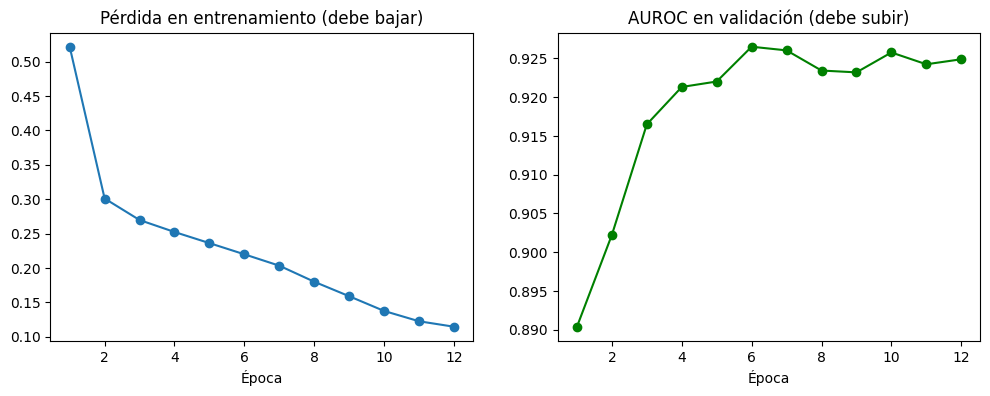

In [38]:
h = pd.DataFrame(historial)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.plot(h.epoca, h.perdida_train, "o-"); a1.set_title("Pérdida en entrenamiento (debe bajar)"); a1.set_xlabel("Época")
a2.plot(h.epoca, h.auc_val, "o-", color="green"); a2.set_title("AUROC en validación (debe subir)"); a2.set_xlabel("Época")
plt.show()

## Paso 6. Examen final

### Elegir el umbral de decisión
El modelo no dice "sí" o "no", sino que da una probabilidad, por ejemplo 0.73. Tenemos que elegir un umbral, y por encima de él la foto es referible.
- Umbral bajo → detecta casi todos los enfermos, con alta sensibilidad, pero manda más sanos al oftalmólogo.
- Umbral alto → al revés.

En tamizaje, dejar escapar a un enfermo es peor que una derivación de más. Por eso elegimos con validación, nunca con el examen final, el umbral que detecta ≥ 90% de los referibles.

### Métricas
- La sensibilidad dice cuántos enfermos detectó.
- La especificidad dice cuántos sanos dejó tranquilos.
- El AUROC es una nota global que va de 0.5, el azar, a 1.0, la perfección, sin depender del umbral.
- El intervalo de confianza al 95% es el rango donde probablemente está el valor real. Para sensibilidad y especificidad usamos el método de Wilson, y para el AUROC un bootstrap que repite el cálculo 1,000 veces con muestras al azar del examen.

In [39]:
from sklearn.metrics import roc_curve, confusion_matrix

# 1. Umbral elegido con VALIDACIÓN
p_val, y_val = predecir(modelo, dl_val)
fpr_v, tpr_v, umbrales_v = roc_curve(y_val, p_val)
idx = np.where(tpr_v >= CONFIG["sensibilidad_objetivo"])[0][0]
umbral = float(min(umbrales_v[idx], 1.0))
print(f"Umbral elegido (en validación): {umbral:.3f}")

# 2. Examen final en PRUEBA
p_test, y_test = predecir(modelo, dl_test)
pred = (p_test >= umbral).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, pred, labels=[0, 1]).ravel()

def wilson(aciertos, total, z=1.96):
    if total == 0:
        return (float("nan"),) * 3
    p = aciertos / total
    centro = (p + z**2 / (2 * total)) / (1 + z**2 / total)
    margen = z * np.sqrt(p * (1 - p) / total + z**2 / (4 * total**2)) / (1 + z**2 / total)
    return p, centro - margen, centro + margen

def auroc_bootstrap(y, p, n=1000, semilla=0):
    rng = np.random.default_rng(semilla)
    valores = []
    for _ in range(n):
        i = rng.integers(0, len(y), len(y))
        if len(np.unique(y[i])) == 2:
            valores.append(roc_auc_score(y[i], p[i]))
    return roc_auc_score(y, p), np.percentile(valores, 2.5), np.percentile(valores, 97.5)

sens = wilson(tp, tp + fn)
esp = wilson(tn, tn + fp)
auc = auroc_bootstrap(y_test, p_test)

print(f"\n══════════ RESULTADO REAL, {CONFIG['version']} ({' + '.join(sorted(df.source_dataset.unique()))}, conjunto de prueba) ══════════")
print(f"Fotos en el examen: {len(y_test)}  (referibles: {int(y_test.sum())})")
print(f"AUROC         : {auc[0]:.3f}  (IC95% {auc[1]:.3f}–{auc[2]:.3f})")
print(f"Sensibilidad  : {sens[0]:.1%}  (IC95% {sens[1]:.1%}–{sens[2]:.1%})  → detectó {tp} de {tp+fn} referibles")
print(f"Especificidad : {esp[0]:.1%}  (IC95% {esp[1]:.1%}–{esp[2]:.1%})  → acertó {tn} de {tn+fp} no referibles")

Umbral elegido (en validación): 0.057

══════════ RESULTADO REAL, model_v3 (APTOS2019 + EyePACS, conjunto de prueba) ══════════
Fotos en el examen: 5540  (referibles: 1226)
AUROC         : 0.930  (IC95% 0.920–0.939)
Sensibilidad  : 90.5%  (IC95% 88.8%–92.1%)  → detectó 1110 de 1226 referibles
Especificidad : 74.0%  (IC95% 72.7%–75.3%)  → acertó 3193 de 4314 no referibles


### Matriz de confusión y curva ROC
- La matriz de confusión cuenta aciertos y errores. La casilla que más nos importa es "Enfermo → dijo sano", los falsos negativos, porque son los pacientes que se escaparían.
- La curva ROC muestra la sensibilidad frente a 1 − especificidad para *todos* los umbrales posibles. El área bajo esa curva es el AUROC. La línea punteada es "adivinar al azar".

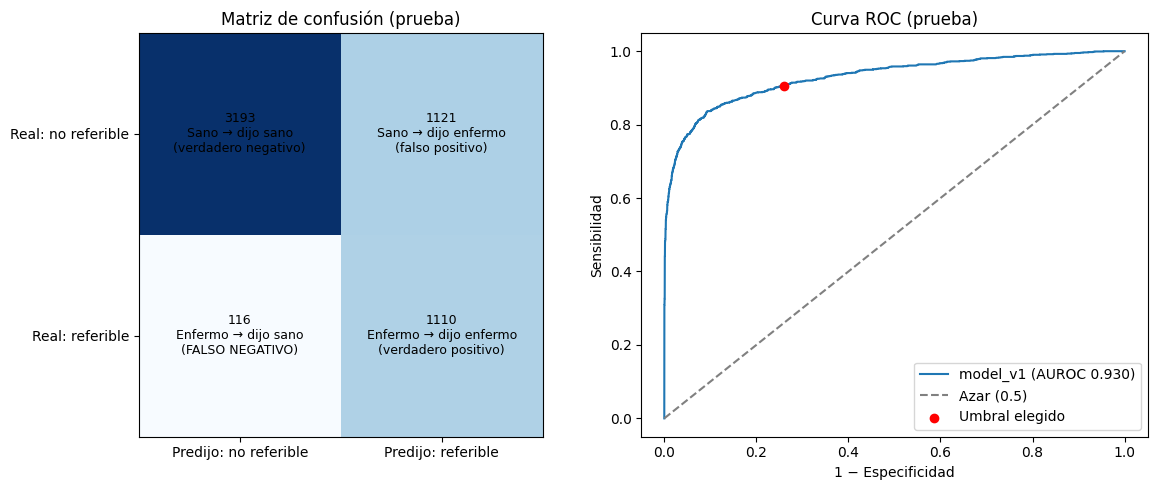

In [40]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 5))
matriz = np.array([[tn, fp], [fn, tp]])
a1.imshow(matriz, cmap="Blues")
etiquetas = [["Sano → dijo sano\n(verdadero negativo)", "Sano → dijo enfermo\n(falso positivo)"],
             ["Enfermo → dijo sano\n(FALSO NEGATIVO)", "Enfermo → dijo enfermo\n(verdadero positivo)"]]
for i in range(2):
    for j in range(2):
        a1.text(j, i, f"{matriz[i, j]}\n{etiquetas[i][j]}", ha="center", va="center", fontsize=9)
a1.set_xticks([0, 1]); a1.set_xticklabels(["Predijo: no referible", "Predijo: referible"])
a1.set_yticks([0, 1]); a1.set_yticklabels(["Real: no referible", "Real: referible"])
a1.set_title("Matriz de confusión (prueba)")

fpr, tpr, _ = roc_curve(y_test, p_test)
a2.plot(fpr, tpr, label=f"model_v1 (AUROC {auc[0]:.3f})")
a2.plot([0, 1], [0, 1], "--", color="gray", label="Azar (0.5)")
a2.scatter([1 - esp[0]], [sens[0]], color="red", zorder=3, label="Umbral elegido")
a2.set_xlabel("1 − Especificidad"); a2.set_ylabel("Sensibilidad"); a2.set_title("Curva ROC (prueba)"); a2.legend()
plt.tight_layout(); plt.show()

## Paso 7. Guardar `model_v1`

Guardamos dos archivos en tu Drive.
- `model_v1.pt` guarda los pesos del modelo, es decir, lo que aprendió. Esto es lo que después irá dentro de la app.
- `model_v1.json` es la "ficha técnica" con la fecha, la configuración, el umbral y las métricas. Corresponde al campo `version_del_modelo` de la tabla `resultados_ia` de la base de datos.

Versionar cada modelo como v1, v2, v3… permite comparar mejoras y saber exactamente qué modelo produjo cada resultado.

In [41]:
import json, datetime
os.makedirs(CARPETA_SALIDA, exist_ok=True)
ruta_pesos = f"{CARPETA_SALIDA}/{CONFIG['version']}.pt"
assert not os.path.exists(ruta_pesos), f"{ruta_pesos} YA EXISTE: cambia CONFIG['version'] para no sobrescribir un modelo anterior"
torch.save(modelo.state_dict(), ruta_pesos)

ficha = dict(
    version=CONFIG["version"],
    fecha=datetime.datetime.now().isoformat(timespec="seconds"),
    datos=" + ".join(sorted(df.source_dataset.unique())) + " (división por paciente, estratificada por grado)",
    fuentes_entrenamiento={k: int(v) for k, v in df_train.source_dataset.value_counts().items()},
    fuentes_examen={k: int(v) for k, v in df_test.source_dataset.value_counts().items()},
    tarea="binaria: referible (ICDR>=2) vs no referible",
    config=CONFIG,
    umbral=umbral,
    test=dict(
        n=int(len(y_test)), referibles=int(y_test.sum()),
        auroc=[round(float(v), 4) for v in auc],
        sensibilidad=[round(float(v), 4) for v in sens],
        especificidad=[round(float(v), 4) for v in esp],
        matriz=dict(tn=int(tn), fp=int(fp), fn=int(fn), tp=int(tp)),
    ),
    historial=historial,
)
with open(f"{CARPETA_SALIDA}/{CONFIG['version']}.json", "w") as f:
    json.dump(ficha, f, indent=2, ensure_ascii=False)
print("Guardado en:", ruta_pesos)
print("Ficha técnica:", f"{CARPETA_SALIDA}/{CONFIG['version']}.json")

Guardado en: /content/drive/MyDrive/Retinopatia_modelos LOCAL/model_v3.pt
Ficha técnica: /content/drive/MyDrive/Retinopatia_modelos LOCAL/model_v3.json


## Listo. ¿Qué sigue?

Anota tus 3 números, AUROC, sensibilidad y especificidad con sus IC. Este es el primer resultado real del proyecto y reemplaza al número simulado del póster.

Como referencia aproximada, en APTOS los modelos de este tipo suelen lograr un AUROC de 0.95 o más para referible vs no referible. Si sale muy por debajo, por ejemplo bajo 0.85, algo falló. Revisa que la GPU estuviera activa y que las fotos de ejemplo se vean bien.

> Un número alto en APTOS no garantiza que funcione con las cámaras del MINSA ni con smartphone. Eso es justo lo que medirá el experimento cross-device con mBRSET, el número clave del proyecto.

#### Próximos pasos, de v2 en adelante
1. Sumar EyePACS, IDRiD y DDR al mismo esquema → más datos, y división por paciente.
2. Probar `usar_clahe=True` y comparar con v1.
3. Mapas de calor con Grad-CAM para ver dónde mira el modelo en la foto, algo importante para el "médico en el loop" y para el jurado.
4. Cuando llegue el acceso a PhysioNet, evaluación zero-shot en las fotos de smartphone de mBRSET y few-shot adaptation.
5. Pasar este código a scripts ordenados en PyCharm con git.

---
### Mini glosario
<table>
<thead><tr><th>Término</th><th>Qué es</th></tr></thead>
<tbody><tr><td>Aprendizaje supervisado</td><td>Aprender de ejemplos que ya traen la respuesta correcta</td></tr></tbody>
<tbody><tr><td>CNN</td><td>Red neuronal especializada en imágenes, que analiza por capas</td></tr></tbody>
<tbody><tr><td>Transfer learning</td><td>Reusar un modelo ya entrenado y especializarlo</td></tr></tbody>
<tbody><tr><td>Época</td><td>Una pasada completa por todas las fotos de estudio</td></tr></tbody>
<tbody><tr><td>Lote o batch</td><td>Grupo de fotos que se procesan juntas antes de corregir</td></tr></tbody>
<tbody><tr><td>Pérdida o loss</td><td>Medida del error, que el modelo intenta bajar</td></tr></tbody>
<tbody><tr><td>Descenso del gradiente</td><td>Método para corregir los pesos en la dirección que más reduce el error</td></tr></tbody>
<tbody><tr><td>Tasa de aprendizaje</td><td>Tamaño de cada corrección</td></tr></tbody>
<tbody><tr><td>Sobreajuste</td><td>Memorizar en vez de entender, algo que se detecta con datos nuevos</td></tr></tbody>
<tbody><tr><td>Aumento de datos</td><td>Mostrar variaciones de las fotos para que el modelo generalice</td></tr></tbody>
<tbody><tr><td>Umbral</td><td>Probabilidad a partir de la cual se dice "referible"</td></tr></tbody>
<tbody><tr><td>AUROC</td><td>Nota global de 0.5, el azar, a 1, la perfección</td></tr></tbody>
<tbody><tr><td>Intervalo de confianza</td><td>Rango donde probablemente está el valor real</td></tr></tbody>
</table>